<a href="https://colab.research.google.com/github/ojaspaul123/DL-journey/blob/main/CNN/CNN_Backpropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. **Forward propagation — the basic flow**

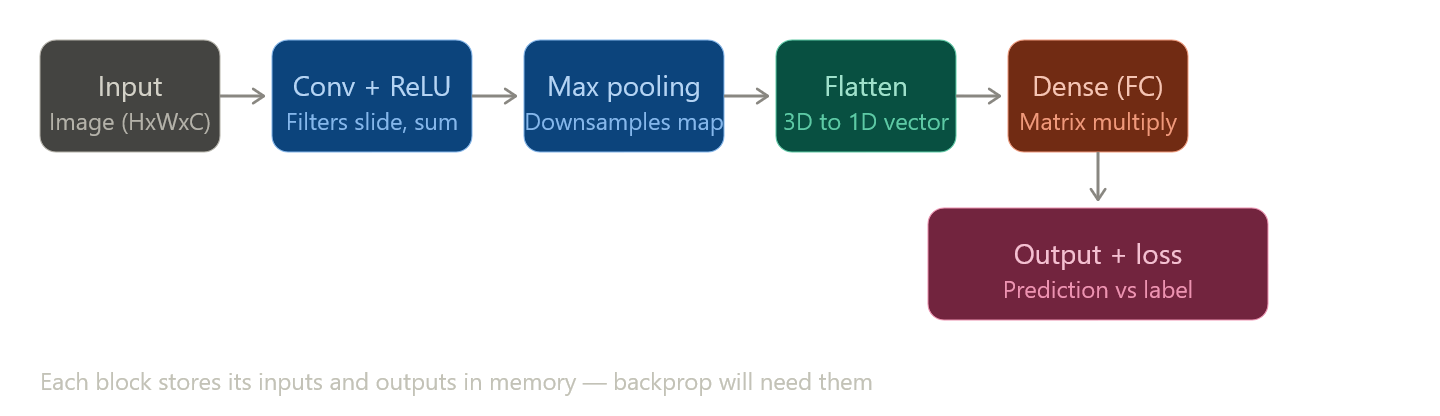


The forward pass, concretely:

1. Convolution: a small filter (say 3×3) slides over the input, computing a dot product at each position, then adding a bias: z = (filter • patch) + b. This is repeated for every filter, producing one feature map per filter.
2. Activation (ReLU): a = max(0, z) applied elementwise. This is what introduces non-linearity.
3. Max pooling: slides a window (say 2×2) over the activated feature map and keeps only the maximum value in each window — this shrinks the spatial size and makes the representation slightly more robust to small shifts.
4. Flatten: takes the final 3D stack of feature maps (height × width × channels) and reshapes it into one long 1D vector, because the next layer (fully connected) expects a flat vector, not a grid.
5. Fully connected layers: standard matrix multiply + bias + activation, same as in an ANN.
6. Output + loss: final layer produces predictions, compared against the true label using a loss function (cross-entropy for classification, MSE for regression).

The crucial thing for backprop later: each layer must cache what it saw during the forward pass (its input, and for max pooling, which position was the max) — backprop needs this information to route gradients correctly.

2. **Trainable parameters — what's actually being learned**

Not every layer has parameters. This trips a lot of people up.

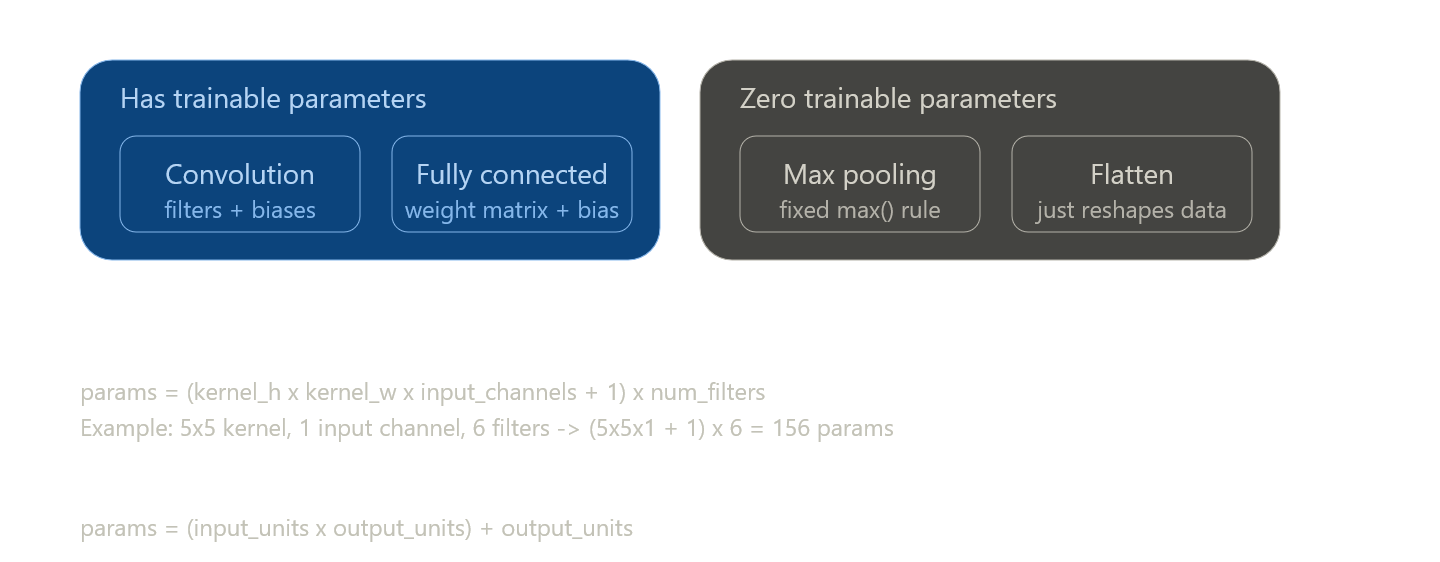

This is the single most important thing to internalize before backprop: max pooling and flatten have nothing to learn. They're fixed, deterministic operations. Backprop still has to pass gradients through them, but it never updates anything inside them — only convolution and fully-connected layers get weight updates.

3. **The backward pass — the chain rule, layer by layer**

Backprop's whole job is computing ∂Loss/∂(every weight), using the chain rule to push the gradient backward from the loss, layer by layer. Each layer type handles this differently because each does a different forward operation.

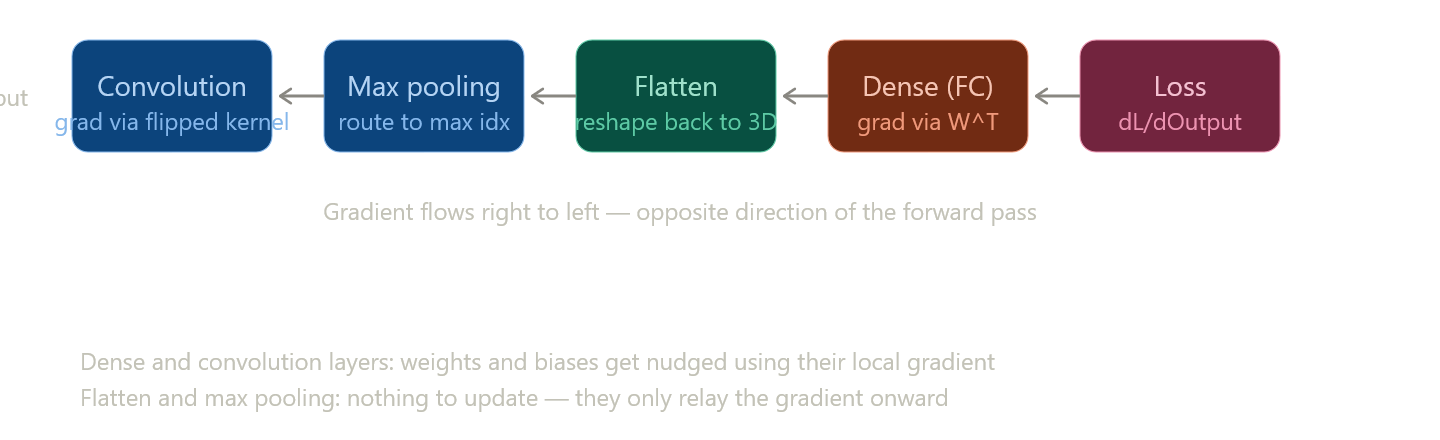

**Backprop through the Flatten layer (simplest — just bookkeeping)**

Flatten took a 3D tensor (H × W × C) and reshaped it into a 1D vector during the forward pass. Backward, it does the exact reverse: it takes the incoming 1D gradient vector and reshapes it back into H × W × C — no math, no transformation of values, just reshaping the same numbers back into their original positions. This is why it has zero trainable parameters: there's nothing to learn, only a shape to restore.   

**Backprop through Max Pooling**   

This is the one with a clever trick. During the forward pass, for each pooling window (say 2×2), only the maximum value gets passed through — the other 3 values are discarded.
During backward, the incoming gradient for that output position gets routed entirely to the position that was the max during the forward pass, and zero gradient goes to the other positions in that window — because changing them slightly wouldn't have changed the output at all (they weren't the max, so they had zero influence on the result).
That's why max pooling layers must cache the index of the max during the forward pass — backprop literally looks up "where did the max come from?" and sends the gradient there, like a router with no learnable weights, just a fixed switchboard.

**Backprop through Convolution (the most involved one)**   

Convolution has two things to compute on the way back:   


1. Gradient with respect to the filter weights (∂L/∂W) — this tells us how to update the filter. It turns out to be the convolution of the layer's input with the incoming gradient — essentially correlating "what was seen" with "how wrong was the result," accumulated across every position the filter slid over (since the same filter weights were reused at every position, their gradients from every position get summed together).

2. Gradient with respect to the layer's input (∂L/∂X) — needed to keep passing the gradient backward to earlier layers. This is computed as a full convolution of the incoming gradient with the filter, flipped 180°. This flip is the famous detail that makes convolution backprop "look like convolution again" — the backward pass of a convolution is, itself, mathematically another convolution.

The bias gradient is simpler — it's just the sum of the incoming gradient over all spatial positions, since the bias was added equally everywhere.

**Putting it together — why this matters in practice**    

The key insight for training a CNN: weight sharing in convolution multiplies the gradient signal. Because the same small filter is reused across the entire image, every single position where it was applied contributes to that filter's gradient. This is exactly why CNNs train efficiently with far fewer parameters than an ANN would need for the same image — fewer weights, but each one gets a much richer, accumulated gradient signal during backprop.